# Send and receive a pulse (tProc v2)

This notebook plays a single constant pulse on generator 0 and captures it on readout 0 through a loopback cable. It plots the decimated I/Q trace and prints the raw samples. On a bitstream with the NN classifier, it also reads back the classifier's ground/excited-state prediction for the pulse.

It is based on the tProc v2 tutorial [`01_Basic_Sequencing.ipynb`](../../../docs/source/tutorials/01_Basic_Sequencing.ipynb), adapted to load a custom bitstream built from this repo. It is the tProc v2 counterpart of the tProc v1 branch's [`qick_ml/send_receive_pulse.ipynb`](https://github.com/GiuseppeDiGuglielmo/qick/blob/ml-integration-tproc-v1-2026/qick_ml/send_receive_pulse.ipynb).

The notebook runs in this order:

1. Check the repo and import this repo's `qick_lib`.
2. Pick and load a bitstream from `216/<branch>/`.
3. Define and run the single-pulse program, then plot the trace.
4. If the bitstream has an NN, configure the classifier and read its prediction.

## Bench setup

Connect the generator's DAC output to the readout's ADC input with an SMA cable. Which DAC port to use depends on the bitstream:

| Bitstream | Generator 0 | Readout 0 |
| --- | --- | --- |
| `qick_216_tprocv2_dac228*` (`DAC = 228`) | DAC tile 0 blk 0: `0_228` on JHC1, QICK box DAC port 0 | ADC tile 2 blk 0: `0_226` on JHC7, ADC port 4 |
| `qick_216_tprocv2_dac230*` (`DAC = 230`) | DAC tile 2 blk 0: `0_230` on JHC3, QICK box DAC port 8 | same |

The tProc v1 `qick_216_orig` bitstream used `0_230`. If the bench is still cabled for it, either move the cable to `0_228` or set `DAC = 230` below to load a bitstream built with `make bitstream DAC=230`. With the cable on the wrong DAC port, the trace is only noise.

## Environment

Run this from an ML branch (e.g. `ml-integration-tproc-v2-2026`) of https://github.com/GiuseppeDiGuglielmo/qick. The branch name picks the bitstream directory, and this repo's `qick_lib` is imported ahead of any system-wide `qick` so that the drivers match the custom firmware.

In [1]:
import subprocess

!git branch
!echo -n "git rev:  "; git rev-parse --short HEAD
!echo -n "git date: "; git log -1 --format=%cd

branch_name = subprocess.getoutput("git rev-parse --abbrev-ref HEAD").replace('/', '-')
print('Bitstream directory: 216/{}'.format(branch_name))

* ml-integration-tproc-v2-2026
git rev:  f9ce12b
git date: Wed Sep 23 15:08:33 2026 -0500
Bitstream directory: 216/ml-integration-tproc-v2-2026


In [2]:
# Use this repo's own qick_lib (its driver bindto strings and IP classes match
# this branch's custom firmware/bitstream) instead of whatever qick package
# happens to be installed system-wide via pip.
import sys, os
repo_qick_lib = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..', 'qick_lib'))
if repo_qick_lib not in sys.path:
    sys.path.insert(0, repo_qick_lib)

# Import the QICK drivers and auxiliary libraries
from qick import *
# tProc v2 programs are built on AveragerProgramV2, not the tProc v1 AveragerProgram
from qick.asm_v2 import AveragerProgramV2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import qick
print('Using qick from:', qick.__file__)

Using qick from: /home/xilinx/jupyter_notebooks/qick-ml-integration-tproc-v2-2026/qick_lib/qick/__init__.py


## Bitstream

`make copy` (in `firmware/tools`) pushes each build's `.bit`, `.hwh` and `.ltx` files from `firmware/projects/qick_tprocv2_216_standard_1ch/out/` to `216/<branch>/` next to this notebook. The `.hwh` file must sit next to the `.bit` file.

Set `DAC` to match the cabling in [Bench setup](#Bench-setup).

In [3]:
# List the custom bitstreams available for this branch
!pwd
!ls -lhR 216/$branch_name

/home/xilinx/jupyter_notebooks/qick-ml-integration-tproc-v2-2026/firmware/notebooks/qick_ml
216/ml-integration-tproc-v2-2026:
total 71M
-rw-rw-r-- 1 xilinx xilinx  33M Sep 23 13:44 qick_216_tprocv2_dac230_ila.bit
-rw-rw-r-- 1 xilinx xilinx 2.5M Sep 23 13:44 qick_216_tprocv2_dac230_ila.hwh
-rw-rw-r-- 1 xilinx xilinx  95K Sep 23 13:44 qick_216_tprocv2_dac230_ila.ltx
-rw-rw-r-- 1 xilinx xilinx  33M Sep 22 22:17 qick_216_tprocv2_ila.bit
-rw-rw-r-- 1 xilinx xilinx 2.5M Sep 22 22:17 qick_216_tprocv2_ila.hwh
-rw-rw-r-- 1 xilinx xilinx  95K Sep 22 22:17 qick_216_tprocv2_ila.ltx


In [4]:
# Generator DAC, to match the cabling: 228 (0_228, JHC1) or 230 (0_230, JHC3)
DAC = 230
DAC_SUFFIX = '_dac{}'.format(DAC)

# Choose custom bitstream (DAC = 230 selects the make bitstream DAC=230 build)
# Filenames match what `make copy` (firmware/tools) pushes from a design's out/
# directory: firmware/projects/qick_tprocv2_216_standard_1ch/out/*.bit

# QICK tProc v2
# CUSTOM_BIT = '216/{}/qick_216_tprocv2{}.bit'.format(branch_name, DAC_SUFFIX)
# HAS_NN = 0

# QICK tProc v2 + readout ILAs
CUSTOM_BIT = '216/{}/qick_216_tprocv2{}_ila.bit'.format(branch_name, DAC_SUFFIX)
HAS_NN = 0

# QICK tProc v2 + NN classifier (not yet built for tProc v2; placeholder for
# when the classifier IP from the tProc v1 branch is ported here)
# CUSTOM_BIT = '216/{}/qick_216_tprocv2_nn.bit'.format(branch_name)
# HAS_NN = 1

# Configure channels
GEN_CH = 0
RO_CH = 0

In [5]:
# Load bitstream with custom overlay
if 'CUSTOM_BIT' not in locals():
    HAS_NN = 0  # the default bitstream has no NN
    soc = QickSoc()
else:
    import os
    # Normalize path
    CUSTOM_BIT_FULL_PATH = os.path.normpath(os.getcwd() + '/' + CUSTOM_BIT)
    print('Custom bitstream:', CUSTOM_BIT_FULL_PATH)

    # The HWH file must sit next to the BIT file
    hwh_path = os.path.splitext(CUSTOM_BIT_FULL_PATH)[0] + '.hwh'
    if not os.path.isfile(hwh_path):
        raise FileNotFoundError('Missing HWH file next to the bitstream: ' + hwh_path)

    soc = QickSoc(bitfile=CUSTOM_BIT_FULL_PATH)

soccfg = soc
print(soccfg)

Custom bitstream: /home/xilinx/jupyter_notebooks/qick-ml-integration-tproc-v2-2026/firmware/notebooks/qick_ml/216/ml-integration-tproc-v2-2026/qick_216_tprocv2_dac230_ila.bit
QICK running on ZCU216, software version 0.2.432

Firmware configuration (built Wed Sep 23 11:18:16 2026):

	Global clocks (MHz): tProc dispatcher timing 430.080, RF reference 245.760
	Groups of related clocks: [tProc timing clock, DAC tile 1, DAC tile 2], [DAC tile 0], [ADC tile 2]

	DAC output power mode: 20mA

	1 signal generator channels:
	0:	axis_signal_gen_v6 - fs=6881.280 Msps, fabric=430.080 MHz
		envelope memory: 65536 complex samples (9.524 us)
		32-bit DDS, range=6881.280 MHz
		DAC tile 2, blk 0 is 0_230 on JHC3, or QICK box DAC port 8

	1 readout channels:
	0:	axis_dyn_readout_v1 - configured by tProc output 1
		fs=2457.600 Msps, decimated=307.200 MHz, 32-bit DDS, range=2457.600 MHz
		axis_avg_buffer v1.2 (has edge counter, no weights)
		memory 8192 accumulated, 4096 decimated (13.333 us)
		triggered b

In [6]:
print('Loaded bitstream:', soccfg.bitfile_name)

Loaded bitstream: /home/xilinx/jupyter_notebooks/qick-ml-integration-tproc-v2-2026/firmware/notebooks/qick_ml/216/ml-integration-tproc-v2-2026/qick_216_tprocv2_dac230_ila.bit


### Hardware Configuration

In [7]:
print('Generator channel {}: {}'.format(GEN_CH, soccfg._describe_dac(soccfg['gens'][GEN_CH]['dac'])))
print('Readout channel   {}: {}'.format(RO_CH, soccfg._describe_adc(soccfg['readouts'][RO_CH]['adc'])))

Generator channel 0: DAC tile 2, blk 0 is 0_230 on JHC3, or QICK box DAC port 8
Readout channel   0: ADC tile 2, blk 0 is 0_226 on JHC7, or QICK box ADC port 4


In [8]:
# Single constant pulse and readout, as in "A Simple Single-Pulse Program" of
# docs/source/tutorials/01_Basic_Sequencing.ipynb
class SinglePulseProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        # Declare the generator and readout channels
        self.declare_gen(ch=cfg['gen_ch'], nqz=1)  # nqz=1 means no frequency folding
        self.declare_readout(ch=cfg['ro_ch'], length=cfg['ro_len'])

        # Define a constant pulse (no envelope shaping)
        self.add_pulse(
            ch=cfg['gen_ch'],
            name="my_pulse",
            style="const",           # Constant amplitude
            freq=cfg['freq'],        # Frequency in MHz
            length=cfg['pulse_len'], # Duration in microseconds
            phase=cfg['phase'],      # Phase in degrees
            gain=cfg['gain']         # Amplitude (0 to 1)
        )

        # Configure the readout
        self.add_readoutconfig(
            ch=cfg['ro_ch'],
            name="my_ro",
            freq=cfg['freq'],
            gen_ch=cfg['gen_ch']
        )
        self.send_readoutconfig(ch=cfg['ro_ch'], name="my_ro", t=0)

    def _body(self, cfg):
        # Play the pulse at time t=0
        self.pulse(ch=cfg['gen_ch'], name="my_pulse", t=0)
        # Trigger the readout
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

### NN scaler setup

### Load an excited state

In [9]:
# Configure the experiment
config = {
    'gen_ch': GEN_CH,
    'ro_ch': RO_CH,
    'freq': 500.0,          # MHz
    'pulse_len': 0.1,       # microseconds
    'phase': 0,             # degrees
    'gain': 1.0,            # full amplitude
    'trig_time': 0.2,       # microseconds (when to start readout)
    'ro_len': 0.5,          # microseconds (readout duration)
    'rounds': 1,           # averages, passed to acquire_decimated
}

In [10]:
#########################################################
# If you are running Vivado ILA, it is time to arm them #
#########################################################

In [11]:
import pynq
print('PYNQ version: {}'.format(pynq.__version__))

PYNQ version: 2.7.0


In [12]:
from pynq import MMIO

if HAS_NN:
    nn_config = soccfg.NN_0

    mmio_nn_config = MMIO(
        nn_config.mmio.base_addr,
        nn_config.mmio.length
    )

    print('NN0 config @{} {:4}KB {:8}w'.format(
        hex(nn_config.mmio.base_addr),
        int(nn_config.mmio.length/1024),
        len(nn_config.mmio.array)
    ))
    print('  - window_size     @{}'.format((nn_config.register_map.window_size.address)))
    print('  - window_offset   @{}'.format((nn_config.register_map.window_offset.address)))
    print('  - scaling_factor  @{}'.format((nn_config.register_map.scaling_factor.address)))
    print('  - out_reset       @{}'.format((nn_config.register_map.out_reset.address)))
    print('  - out_offset      @{}'.format((nn_config.register_map.out_offset.address)))
    print('      - value        {}'.format(mmio_nn_config.read(
                                        nn_config.register_map.out_offset.address)))
    print('  - out_offset_ctrl @{}'.format((nn_config.register_map.out_offset_ctrl.address)))
else:
    print('No NN')

No NN


In [13]:
import qick_ml_lib
from qick_ml_lib import (to_float, reset_classifier, configure_classifier,
                          get_classifier_prediction_count, get_classifier_prediction,
                          get_classifier_predictions, print_classifier_buffer)

# The classifier helpers live in qick_ml_lib.py and need the SoC handle registered once
qick_ml_lib.set_soccfg(soccfg)

In [14]:
%%time
if HAS_NN:
    if 'WINDOW_SIZE' not in globals():
        WINDOW_SIZE = 400  # default, unless set in the bitstream cell
    WINDOW_OFFSET = 5
    SCALING_FACTOR = 1

    # Reset the classifier in deep mode (first 16 predictions, i.e. 32 words, of the buffer are set to 0)
    reset_classifier(deep_reset=True, index_lo=0, index_hi=15)

    # The NN IP ignores the WINDOW_SIZE for now
    configure_classifier(WINDOW_SIZE, WINDOW_OFFSET, SCALING_FACTOR, debug=True)

CPU times: user 13 µs, sys: 1e+03 ns, total: 14 µs
Wall time: 24.3 µs


In [15]:
if HAS_NN:
    print_classifier_buffer(index_lo=0, index_hi=7)

  0%|          | 0/1 [00:00<?, ?it/s]

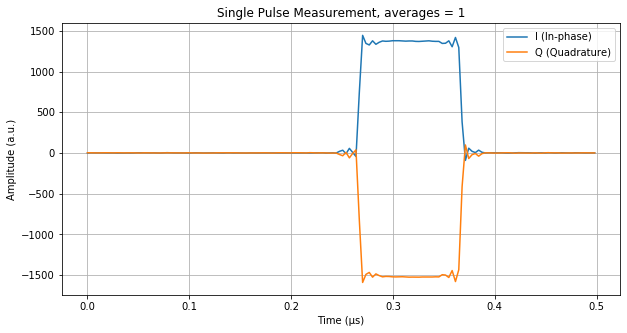

CPU times: user 1.12 s, sys: 28.1 ms, total: 1.15 s
Wall time: 1.15 s


In [16]:
%%time
# Create and run the program
prog = SinglePulseProgram(soccfg, reps=1, final_delay=0.5, cfg=config)

# Acquire data (decimated mode gives IQ traces vs time)
iq_data = prog.acquire_decimated(soc, rounds=config['rounds'])
time_axis = prog.get_time_axis(ro_index=0)

# Plot the results
plt.figure(figsize=(10, 5))
if HAS_NN:
    plt.axvline(WINDOW_OFFSET, ls='--', color='red')
    plt.axvline(WINDOW_OFFSET + WINDOW_SIZE, ls='--', color='red')
plt.plot(time_axis, iq_data[0][:,0], label='I (In-phase)')
plt.plot(time_axis, iq_data[0][:,1], label='Q (Quadrature)')
#plt.plot(time_axis, np.abs(iq_data[0].dot([1,1j])), label='Magnitude')
plt.legend()
plt.xlabel('Time (µs)')
plt.ylabel('Amplitude (a.u.)')
plt.title('Single Pulse Measurement, averages = {}'.format(config['rounds']))
plt.grid(True)
plt.show()

In [24]:
from qick_ml_lib import float_to_hex32, int_to_twos_complement_hex32

# Take the trace from the first (and only) readout channel.
iq = iq_data[0]

# Interleave I and Q into a single flat sequence: I[0], Q[0], I[1], Q[1], ...
# (iq is an Nx2 array of [I, Q] rows, so flattening it in row-major order already interleaves them)
iq_sequence = [int(v) for v in iq.flatten()]

# Encode each sample as hex: as an IEEE-754 float, and as a 32b two's-complement int
hex_iq_sequence_flt = [float_to_hex32(num) for num in iq_sequence]
hex_iq_sequence_dec = [int_to_twos_complement_hex32(int(i)) for i in iq_sequence]

print('Sequence length:', len(iq_sequence))

# Debug: uncomment to dump the raw I/Q arrays or the encoded hex sequences
# print('I (lo, data[15:0])')
# print(iq[:, 0])
# print('Q (hi, data[31:16])')
# print(iq[:, 1])
# print(iq_sequence)
# print(hex_iq_sequence_flt)
# print(hex_iq_sequence_dec)

for i in range(0, len(iq_sequence), 2):
    print("I[{:4d}] {:8d} {}".format(i//2, iq_sequence[i], hex_iq_sequence_dec[i]))
    print("Q[{:4d}] {:8d} {}".format(i//2, iq_sequence[i+1], hex_iq_sequence_dec[i+1]))

Sequence length: 308
I[   0]       -2 fffffffe
Q[   0]        2 00000002
I[   1]        1 00000001
Q[   1]        1 00000001
I[   2]        1 00000001
Q[   2]       -1 ffffffff
I[   3]        0 00000000
Q[   3]        0 00000000
I[   4]        1 00000001
Q[   4]        1 00000001
I[   5]        0 00000000
Q[   5]        1 00000001
I[   6]       -1 ffffffff
Q[   6]        2 00000002
I[   7]       -1 ffffffff
Q[   7]        1 00000001
I[   8]       -1 ffffffff
Q[   8]        0 00000000
I[   9]        0 00000000
Q[   9]        2 00000002
I[  10]       -2 fffffffe
Q[  10]        1 00000001
I[  11]       -3 fffffffd
Q[  11]        0 00000000
I[  12]       -1 ffffffff
Q[  12]        1 00000001
I[  13]       -2 fffffffe
Q[  13]        1 00000001
I[  14]       -1 ffffffff
Q[  14]        1 00000001
I[  15]        2 00000002
Q[  15]        0 00000000
I[  16]        2 00000002
Q[  16]       -1 ffffffff
I[  17]        1 00000001
Q[  17]        1 00000001
I[  18]        1 00000001
Q[  18]        1 

In [18]:
#
# ATTENTION: if the cell fails, please make sure that
#            the base_address matches the associated
#            value in the address editor of the Vivado
#            project.
#
if HAS_NN:
    for i in range(1):
        ground_state_logit, excited_state_logit = get_classifier_prediction(i)

        if to_float(ground_state_logit) > to_float(excited_state_logit):
            print("Prediction: ground state")
        else:
            print("Prediction: excited state")
        print('Logit values as int: [{}, {}]'.format(ground_state_logit, excited_state_logit))
        print('Logit values as hex: [{}, {}]'.format(hex(ground_state_logit), hex(excited_state_logit)))
        print('Logit values as flt: [{}, {}]'.format(to_float(ground_state_logit), to_float(excited_state_logit)))
else:
    print('No NN in this bitstream!')

No NN in this bitstream!


In [19]:
if HAS_NN:
    print_classifier_buffer(index_lo=0, index_hi=7)

In [20]:
if HAS_NN:
    reset_classifier(deep_reset=True, index_hi=7)

In [21]:
if HAS_NN:
    print_classifier_buffer(index_lo=0, index_hi=7)

In [22]:
if HAS_NN:
    print('Readout count: {}'.format(get_classifier_prediction_count()))